# Base de Données Relationnelles
- SGBDR : Système de Gestion de Base de Données Relationnelle
- RDBMS : Relational Data Base Management System

Langage SQL (standard)

In [22]:
import pandas as pd
import sqlite3
from pathlib import Path
from sqlalchemy import create_engine
import requests
import json

## Bas niveau
Utiliser un module d'accès direct la base de l'éditeur (Oracle, Micorsoft, PostgreSQL, ...).

Module conforme PEP 249 : – Python Database API Specification v2.0

In [2]:
sql_table = """
CREATE TABLE IF NOT EXISTS ville (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        code_postal TEXT    NOT NULL,
        nom         TEXT    NOT NULL,
        population  INTEGER,
        superficie  INTEGER
    )
"""

In [3]:
db_ville_sqlite = Path('data/db_ville_sqlite.db')
conn = sqlite3.connect(db_ville_sqlite)
conn

In [4]:
# creér la table
cursor = conn.cursor()
cursor.execute(sql_table)
cursor.close()

In [5]:
# ajout
sql_add_ville ="""
INSERT INTO ville 
(nom, code_postal, population, superficie)
VALUES
('Pau', '64000', 77000, 55)
"""

cursor = conn.cursor()
cursor.execute(sql_add_ville)
cursor.close()
conn.commit()

In [6]:
sql_add_ville ="""
INSERT INTO ville 
(nom, code_postal, population, superficie)
VALUES
(?, ?, ?, ?)
"""

cursor = conn.cursor()
cursor.execute(sql_add_ville, ('Paris', '75000', 2_000_000, 102))
cursor.close()
conn.commit()

In [7]:
sql_all_ville = """
SELECT id, nom, code_postal, population, superficie
FROM ville
ORDER BY population DESC
"""

cursor = conn.cursor()
cursor.execute(sql_all_ville) # la requete est envoyée à la base, 
# le cursor est en attente de l'exploitation du résultat


In [8]:
for ville in cursor:
    print(ville)

(2, 'Paris', '75000', 2000000, 102)
(1, 'Pau', '64000', 77000, 55)


In [9]:
conn.close()

## SqlAlchemy + Pandas

In [10]:
engine = create_engine(f"sqlite:///{db_ville_sqlite}", echo=False)
engine

Engine(sqlite:///data\db_ville_sqlite.db)

In [11]:
# test manuel
c = engine.connect()
c.close()
c

In [12]:
villes = pd.read_sql_table('ville', engine)
villes

,id,code_postal,nom,population,superficie
0,1,64000,Pau,77000,55
1,2,75000,Paris,2000000,102


In [13]:
villes_100k = pd.read_json('data/villes100k.json', orient='records')
villes_100k

,nom_standard,nom_sans_pronom,dep_code,dep_nom,code_postal,population,superficie_km2
0,Nice,Nice,6,Alpes-Maritimes,6000,348085,74
1,Aix-en-Provence,Aix-en-Provence,13,Bouches-du-Rhône,13100,147478,188
2,Marseille,Marseille,13,Bouches-du-Rhône,13000,873076,241
3,Caen,Caen,14,Calvados,14000,108200,26
4,Dijon,Dijon,21,Côte-d'Or,21000,159346,42
5,Besançon,Besançon,25,Doubs,25000,119198,65
6,Brest,Brest,29,Finistère,29200,139619,49
7,Nîmes,Nîmes,30,Gard,30900,148104,161
8,Toulouse,Toulouse,31,Haute-Garonne,31100,504078,118
9,Bordeaux,Bordeaux,33,Gironde,33300,261804,50


In [14]:
villes_100k.to_sql('villes100k', engine)

42

In [19]:
sql_ville_seuil = """
SELECT nom_standard, code_postal, population, superficie_km2
FROM villes100k
WHERE population >= :seuil
ORDER BY population DESC
"""
extrait = pd.read_sql_query(sql_ville_seuil, engine, params={'seuil': 200_000})
extrait

,nom_standard,code_postal,population,superficie_km2
0,Paris,75000,2133111,105
1,Marseille,13000,873076,241
2,Lyon,69000,522250,48
3,Toulouse,31100,504078,118
4,Nice,6000,348085,74
5,Nantes,44200,323204,66
6,Montpellier,34080,302454,57
7,Strasbourg,67000,291313,78
8,Bordeaux,33300,261804,50
9,Lille,59260,236710,35


## ORM : Object Relational Mapper
Correspondance table/row <=> class/object.

Ex: les lignes de la table ville et des objets d'un classe Ville.

En Python : 
- SQLAlchemy ORM
- Django ORM

In [ ]:
class Ville(Base):
    __tablename__ = "villes"

    # Colonnes typées avec Mapped[T] (SQLAlchemy 2.0 style)
    id:          Mapped[int] = mapped_column(Integer, primary_key=True, autoincrement=True)
    code_postal: Mapped[str] = mapped_column(String(10))
    nom:         Mapped[str] = mapped_column(String(100))
    population:  Mapped[int] = mapped_column(Integer)
    superficie:  Mapped[int] = mapped_column(Integer)

## Call API

In [54]:
query = "https://data.toulouse-metropole.fr/api/explore/v2.1/catalog/datasets/12-station-meteo-toulouse-montaudran/records?where=heure_de_paris%20%3E%3D%20%272026-06-18T00%3A00%3A00%2B00%3A00%27&order_by=heure_de_paris&limit=100"

In [55]:
response = requests.get(query)
response.status_code

200

In [56]:
data = response.json()
data

{'total_count': 137,
 'results': [{'data': '18d27032cdc000000c600000',
   'id': 12,
   'humidite': 56,
   'direction_du_vecteur_de_vent_max': 0,
   'pluie_intensite_max': 0.0,
   'pression': 99900,
   'direction_du_vecteur_vent_moyen': 0,
   'type_de_station': 'ISS',
   'pluie': 0.0,
   'direction_du_vecteur_de_vent_max_en_degres': 0.0,
   'force_moyenne_du_vecteur_vent': 0,
   'force_rafale_max': 0,
   'temperature_en_degre_c': 25.3,
   'heure_de_paris': '2026-06-18T00:00:00+00:00',
   'heure_utc': '2026-06-18T00:00:00+00:00'},
  {'data': '18d27052c1c000000c600000',
   'id': 12,
   'humidite': 56,
   'direction_du_vecteur_de_vent_max': 0,
   'pluie_intensite_max': 0.0,
   'pression': 99900,
   'direction_du_vecteur_vent_moyen': 0,
   'type_de_station': 'ISS',
   'pluie': 0.0,
   'direction_du_vecteur_de_vent_max_en_degres': 0.0,
   'force_moyenne_du_vecteur_vent': 0,
   'force_rafale_max': 0,
   'temperature_en_degre_c': 25.0,
   'heure_de_paris': '2026-06-18T00:15:00+00:00',
   'heur

In [57]:
temperatures = pd.DataFrame(data['results'])
temperatures.head()

,data,id,humidite,direction_du_vecteur_de_vent_max,pluie_intensite_max,pression,direction_du_vecteur_vent_moyen,type_de_station,pluie,direction_du_vecteur_de_vent_max_en_degres,force_moyenne_du_vecteur_vent,force_rafale_max,temperature_en_degre_c,heure_de_paris,heure_utc
0,18d27032cdc000000c600000,12,56,0,0.0,99900,0,ISS,0.0,0.0,0,0,25.3,2026-06-18T00:00:00+00:00,2026-06-18T00:00:00+00:00
1,18d27052c1c000000c600000,12,56,0,0.0,99900,0,ISS,0.0,0.0,0,0,25.0,2026-06-18T00:15:00+00:00,2026-06-18T00:15:00+00:00
2,18d27072a1c800000c600000,12,57,0,0.0,99900,0,ISS,0.0,0.0,0,0,24.8,2026-06-18T00:30:00+00:00,2026-06-18T00:30:00+00:00
3,18d2709295d000000c600000,12,58,0,0.0,99900,0,ISS,0.0,0.0,0,0,24.5,2026-06-18T00:45:00+00:00,2026-06-18T00:45:00+00:00
4,18d270b289d000000c600000,12,58,0,0.0,99900,0,ISS,0.0,0.0,0,0,24.2,2026-06-18T01:00:00+00:00,2026-06-18T01:00:00+00:00


In [58]:
temperatures.heure_utc.min(), temperatures.heure_utc.max()

('2026-06-18T00:00:00+00:00', '2026-06-19T04:00:00+00:00')

<Axes: xlabel='heure_de_paris'>

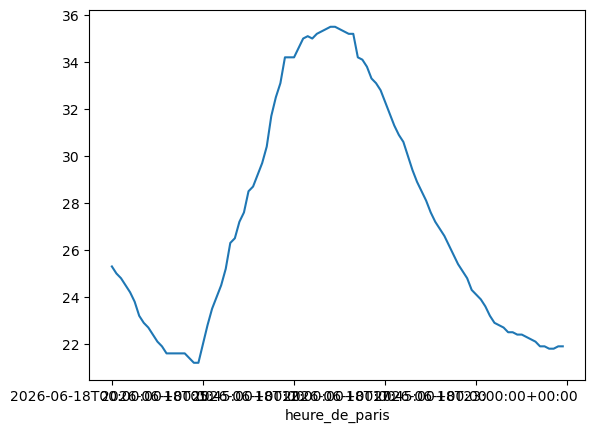

In [59]:
temperatures.set_index('heure_de_paris').temperature_en_degre_c.plot()

In [60]:
# relecture depuis le jeu de données complet
temperatures = pd.read_json('data/12-station-meteo-toulouse-montaudran.json')
temperatures.head()

,data,id,humidite,direction_du_vecteur_de_vent_max,pluie_intensite_max,pression,direction_du_vecteur_vent_moyen,type_de_station,pluie,direction_du_vecteur_de_vent_max_en_degres,force_moyenne_du_vecteur_vent,force_rafale_max,temperature_en_degre_c,heure_de_paris,heure_utc
0,19300bd1a25000000c800000,12,74.0,0.0,0.0,100000.0,0.0,ISS,0.0,0.0,0.0,0.0,20.8,2019-09-17T01:15:00+02:00,2019-09-16T23:15:00+00:00
1,192f0733c94800010cd84c00,12,41.0,12.0,0.0,100200.0,0.0,ISS,0.0,270.0,8.0,19.0,29.2,2019-09-15T16:00:00+02:00,2019-09-15T14:00:00+00:00
2,192f0713a55000010cd04c00,12,42.0,8.0,0.0,100200.0,0.0,ISS,0.0,180.0,8.0,19.0,28.9,2019-09-15T15:45:00+02:00,2019-09-15T13:45:00+00:00
3,192e0993253800006d302000,12,39.0,8.0,0.0,100500.0,0.0,ISS,0.0,180.0,3.0,8.0,26.9,2019-09-14T20:45:00+02:00,2019-09-14T18:45:00+00:00
4,192702ef964000000d200000,12,72.0,0.0,0.0,100500.0,0.0,ISS,0.0,0.0,0.0,0.0,12.5,2019-09-07T07:30:00+02:00,2019-09-07T05:30:00+00:00


In [61]:
temperatures.info()

<class 'pandas.DataFrame'>
RangeIndex: 129394 entries, 0 to 129393
Data columns (total 15 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   data                                        129394 non-null  str    
 1   id                                          129394 non-null  int64  
 2   humidite                                    129393 non-null  float64
 3   direction_du_vecteur_de_vent_max            129393 non-null  float64
 4   pluie_intensite_max                         129393 non-null  float64
 5   pression                                    129393 non-null  float64
 6   direction_du_vecteur_vent_moyen             129393 non-null  float64
 7   type_de_station                             129393 non-null  str    
 8   pluie                                       129393 non-null  float64
 9   direction_du_vecteur_de_vent_max_en_degres  129393 non-null  float64
 10  force_m

<Axes: xlabel='heure_utc'>

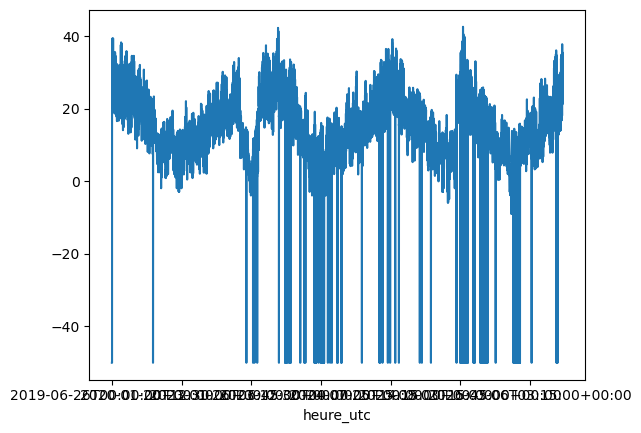

In [63]:
temperatures.set_index('heure_utc').sort_index().temperature_en_degre_c.plot()